# Lecture 8 — Neural Network Library Abstractions

**CMU 10-414/714, Deep Learning Systems (lecture by Tianqi Chen)**
Companion notebook · Sangram Lembe

Lecture 6 built a tensor that remembers how it was computed, and an autodiff engine on top. That
is enough to train a network, but not enough to *build* one comfortably. This lecture is about the
layer above: which interface a framework should expose, and which pieces a model decomposes into.

Part 1 implements the three historical answers — Caffe's layers, TensorFlow 1.0's declarative
graph, PyTorch's define-by-run — on one example, so their trade-offs are visible rather than
described. Part 2 builds a small module library (`Module`, `Parameter`, `Linear`, `Residual`, a
loss, optimizers, a data loader) on the lecture 6 engine and trains a residual network with it.

The running example, from the lecture:

$$v_2 = e^{v_1}, \qquad v_3 = v_2 + 1, \qquad v_4 = v_2 \cdot v_3$$

At $v_1 = 1$: $v_4 = e(e+1) \approx 10.107$, and $dv_4/dv_1 = e(2e+1) \approx 17.496$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

E = np.e
print("v4        =", E * (E + 1))
print("dv4/dv1   =", E * (2*E + 1))

v4        = 10.107337927389695
dv4/dv1   = 17.496394026320345


# Part 1 — three programming abstractions

## 1a. Caffe 1.0: layers with `forward` and `backward`

The first-generation abstraction is the **layer**. Each one owns two methods: `forward` reads
`bottom` and writes `top`; `backward` reads the gradient of `top` and writes the gradient of
`bottom`, in place. Training calls `forward` over the layers in order, `backward` in reverse.

This is what anyone would design after learning backpropagation and nothing else — Tianqi notes
his own early libraries came out the same shape. Notice that **every layer hand-writes its own
gradient**.

In [2]:
class Blob:
    """Caffe's container: data plus a gradient buffer of the same shape."""
    def __init__(self, data=0.0):
        self.data, self.diff = np.float64(data), 0.0

class ExpLayer:
    def forward(self, bottom, top):
        top[0].data = np.exp(bottom[0].data)
    def backward(self, top, bottom):
        bottom[0].diff += top[0].data * top[0].diff        # d exp(x) = exp(x)

class AddScalarLayer:
    def __init__(self, c): self.c = c
    def forward(self, bottom, top):
        top[0].data = bottom[0].data + self.c
    def backward(self, top, bottom):
        bottom[0].diff += top[0].diff

class MulLayer:
    def forward(self, bottom, top):
        top[0].data = bottom[0].data * bottom[1].data
    def backward(self, top, bottom):
        bottom[0].diff += bottom[1].data * top[0].diff      # product rule, by hand
        bottom[1].diff += bottom[0].data * top[0].diff

v1, v2, v3, v4 = Blob(1.0), Blob(), Blob(), Blob()
net = [(ExpLayer(),        [v1],     [v2]),
       (AddScalarLayer(1), [v2],     [v3]),
       (MulLayer(),        [v2, v3], [v4])]

for layer, bottom, top in net:                 # forward, in order
    layer.forward(bottom, top)
v4.diff = 1.0
for layer, bottom, top in reversed(net):       # backward, in reverse
    layer.backward(top, bottom)

print(f"v4       = {v4.data:.4f}")
print(f"dv4/dv1  = {v1.diff:.4f}")

v4       = 10.1073
dv4/dv1  = 17.4964


Correct. But look at what it cost: three `backward` methods, each derived by hand. Add a new kind
of layer — say a residual block — and you must derive and code its backward pass too. We come back
to this at the end, because it is the decision that separates this generation from the next.

## 1b. TensorFlow 1.0: declare, then run

The second generation separates **describing** a computation from **running** it. Building the
graph does no arithmetic; values only exist inside `session.run`, and you ask for exactly the
node you want. Below, every node counts how often it is actually evaluated.

In [3]:
class Node:
    count = 0
    def __init__(self, fn, inputs, name):
        self.fn, self.inputs, self.name = fn, inputs, name
    def __add__(self, c):  return Node(lambda a: a + c, [self], "add")
    def __mul__(self, o):  return Node(lambda a, b: a * b, [self, o], "mul")

def placeholder(name):     return Node(None, [], name)
def tf_exp(x):             return Node(np.exp, [x], "exp")

class Session:
    """Evaluate only what the requested node depends on."""
    def run(self, target, feed_dict):
        cache = dict(feed_dict)
        def ev(node):
            if node not in cache:
                Node.count += 1
                cache[node] = node.fn(*[ev(i) for i in node.inputs])
            return cache[node]
        return ev(target)

# --- declaration: no arithmetic happens here
v1 = placeholder("v1")
v2 = tf_exp(v1)
v3 = v2 + 1
v4 = v2 * v3
print("value of v2 after declaring it? There isn't one:", getattr(v2, "value", "undefined"))

sess = Session()
Node.count = 0
print(f"\nsess.run(v4) = {sess.run(v4, {v1: 1.0}):.4f}   nodes evaluated: {Node.count}")
Node.count = 0
print(f"sess.run(v3) = {sess.run(v3, {v1: 1.0}):.4f}   nodes evaluated: {Node.count}  (v4 never computed)")

value of v2 after declaring it? There isn't one: undefined

sess.run(v4) = 10.1073   nodes evaluated: 3
sess.run(v3) = 3.7183   nodes evaluated: 2  (v4 never computed)


Asking for $v_3$ evaluates two nodes and skips $v_4$ entirely — the system saw the whole graph
before running anything. That is the declarative advantage: whole-graph optimisation (dead-code
elimination, fusion, memory reuse), and the freedom to run the session on a different machine
from the Python. The cost: before `run`, there is nothing to `print`.

## 1c. PyTorch and needle: define by run

The third generation computes each value the moment its node is created. So intermediate values
exist, `print` works, and — the real prize — ordinary Python control flow can depend on them. The
graph can be different on every run, which is why this is called a **dynamic** graph.

In [4]:
class Eager:
    """Minimal define-by-run value: computes immediately, remembers its inputs."""
    def __init__(self, value, parents=()):
        self.value, self.parents = float(value), parents
    def __add__(self, c): return Eager(self.value + c, (self,))
    def __mul__(self, o): return Eager(self.value * o.value, (self, o))

def exp_(x): return Eager(np.exp(x.value), (x,))

def depth(v):
    return 1 + max((depth(p) for p in v.parents), default=0)

for start in (1.0, -3.0):
    v1 = Eager(start)
    v2 = exp_(v1)
    v3 = v2 + 1
    v4 = v2 * v3
    print(f"v1 = {start:>4}:  v2 is already {v2.value:.4f}   ", end="")
    if v4.value > 0.5:                 # plain Python, deciding on a real value
        v5 = v4 * Eager(2.0)
    else:
        v5 = v4
    print(f"v5 = {v5.value:.4f}   graph depth {depth(v5)}")

v1 =  1.0:  v2 is already 2.7183   v5 = 20.2147   graph depth 5
v1 = -3.0:  v2 is already 0.0498   v5 = 0.0523   graph depth 4


Two inputs, two different graphs — the branch was chosen by a value that only exists because it
was computed eagerly. In TensorFlow 1.0 that `if` would need a special graph node (`tf.cond`).
This is what makes models like stochastic depth, or sequence models unrolled to the length of each
input, natural to write.

| | Caffe 1.0 | TensorFlow 1.0 | PyTorch / needle |
|---|---|---|---|
| unit | layer | static graph | tensor, graph built as it runs |
| gradients | hand-written per layer | graph extension | graph extension |
| values exist | after `forward` | only inside `run` | immediately |
| optimisation scope | per layer | whole graph | limited |
| control flow | fixed network | special nodes | plain Python |

# Part 2 — a module library, on top of autodiff

## 2a. The tensor level (from lecture 6)

This is the lecture 6 engine, compacted. Everything in Part 2 sits on it. It handles every
gradient; nothing above it will ever write a `backward`.

In [5]:
class Tensor:
    def __init__(self, data, op=None, inputs=(), requires_grad=True):
        self.data = np.asarray(data, dtype=np.float64)
        self.op, self.inputs, self.requires_grad = op, list(inputs), requires_grad
        self.grad = None
    shape = property(lambda s: s.data.shape)
    def __add__(s, o):  return EAdd()(s, o) if isinstance(o, Tensor) else AddS(o)(s)
    def __mul__(s, o):  return EMul()(s, o) if isinstance(o, Tensor) else MulS(o)(s)
    def __sub__(s, o):  return s + (o * -1.0 if isinstance(o, Tensor) else -o)
    def __truediv__(s, c): return MulS(1.0 / c)(s)
    def __matmul__(s, o):  return MatMul()(s, o)
    __radd__, __rmul__ = __add__, __mul__
    def backward(self):
        backprop(self, Tensor(np.ones_like(self.data), requires_grad=False))

class Op:
    def __call__(self, *ins):
        return Tensor(self.compute(*[i.data for i in ins]), op=self, inputs=ins,
                      requires_grad=any(i.requires_grad for i in ins))
    def grads(self, g, node):
        r = self.gradient(g, node)
        return r if isinstance(r, tuple) else (r,)

class EAdd(Op):
    compute = lambda s, a, b: a + b
    gradient = lambda s, g, n: (g, g)
class AddS(Op):
    def __init__(s, c): s.c = c
    compute = lambda s, a: a + s.c
    gradient = lambda s, g, n: g
class EMul(Op):
    compute = lambda s, a, b: a * b
    gradient = lambda s, g, n: (g * n.inputs[1], g * n.inputs[0])
class MulS(Op):
    def __init__(s, c): s.c = c
    compute = lambda s, a: a * s.c
    gradient = lambda s, g, n: g * s.c
class MatMul(Op):
    compute = lambda s, a, b: a @ b
    gradient = lambda s, g, n: (g @ transpose(n.inputs[1]), transpose(n.inputs[0]) @ g)
class Transpose(Op):
    compute = lambda s, a: a.T
    gradient = lambda s, g, n: transpose(g)
class Reshape(Op):
    def __init__(s, shape): s.shape = shape
    compute = lambda s, a: a.reshape(s.shape)
    gradient = lambda s, g, n: reshape(g, n.inputs[0].shape)
class BroadcastTo(Op):
    def __init__(s, shape): s.shape = shape
    compute = lambda s, a: np.broadcast_to(a, s.shape).copy()
    def gradient(s, g, n):                         # broadcast forward = sum backward
        ins = n.inputs[0].shape
        pad = len(s.shape) - len(ins)
        axes = tuple(range(pad)) + tuple(pad + i for i, d in enumerate(ins)
                                         if d == 1 and s.shape[pad + i] != 1)
        return reshape(summation(g, axes) if axes else g, ins)
class Summation(Op):
    def __init__(s, axes=None): s.axes = axes
    compute = lambda s, a: a.sum(axis=s.axes)
    def gradient(s, g, n):
        ins = n.inputs[0].shape
        ax = range(len(ins)) if s.axes is None else (s.axes if isinstance(s.axes, tuple) else (s.axes,))
        keep = tuple(1 if i in ax else d for i, d in enumerate(ins))
        return broadcast_to(reshape(g, keep), ins)
class ReLU_(Op):
    compute = lambda s, a: np.maximum(0, a)
    gradient = lambda s, g, n: g * Tensor((n.inputs[0].data > 0) * 1.0, requires_grad=False)
class Exp(Op):
    compute = lambda s, a: np.exp(a)
    gradient = lambda s, g, n: g * exp(n.inputs[0])
class LogSumExp(Op):
    compute = lambda s, a: (np.log(np.exp(a - a.max(1, keepdims=True)).sum(1)) + a.max(1))
    def gradient(s, g, n):
        z = n.inputs[0]
        sm = exp(z - broadcast_to(reshape(n, (z.shape[0], 1)), z.shape))   # softmax
        return broadcast_to(reshape(g, (z.shape[0], 1)), z.shape) * sm

transpose    = lambda a: Transpose()(a)
reshape      = lambda a, s: Reshape(s)(a)
broadcast_to = lambda a, s: BroadcastTo(s)(a)
summation    = lambda a, axes=None: Summation(axes)(a)
relu         = lambda a: ReLU_()(a)
exp          = lambda a: Exp()(a)
logsumexp    = lambda a: LogSumExp()(a)

def backprop(out, seed):
    """Reverse topological order; partial adjoints accumulate per node."""
    order, seen = [], set()
    def visit(t):
        if id(t) in seen: return
        seen.add(id(t))
        for i in t.inputs: visit(i)
        order.append(t)
    visit(out)
    parts = {id(out): [seed]}
    for node in reversed(order):
        if id(node) not in parts: continue
        g = parts[id(node)][0]
        for extra in parts[id(node)][1:]: g = g + extra
        node.grad = g
        if node.op is not None:
            for inp, p in zip(node.inputs, node.op.grads(g, node)):
                if inp.requires_grad:
                    parts.setdefault(id(inp), []).append(p)

# sanity check against the running example
x = Tensor([1.0]); y = exp(x) * (exp(x) + 1); y.backward()
print("engine: dv4/dv1 =", float(x.grad.data[0]), "  expected", E * (2*E + 1))

engine: dv4/dv1 = 17.496394026320345   expected 17.496394026320345


## 2b. The module level

A `Module` is any block in a network diagram, at any level of nesting. The design rules from the
lecture:

- **tensor in, tensor out**, so any module's output can feed any other's input
- a module **owns its parameters** and can report them recursively, so an optimizer can find them
- a module **initialises** its parameters when it is constructed
- a module may behave differently in **training** and **inference**

In [6]:
class Parameter(Tensor):
    """A leaf tensor that a Module owns and an optimizer updates."""
    def __init__(self, data):
        super().__init__(data, requires_grad=True)

class Module:
    training = True

    def parameters(self):
        """Walk attributes recursively and collect every Parameter."""
        out = []
        for v in self.__dict__.values():
            if isinstance(v, Parameter):
                out.append(v)
            elif isinstance(v, Module):
                out += v.parameters()
            elif isinstance(v, (list, tuple)):
                for item in v:
                    if isinstance(item, Module):
                        out += item.parameters()
        return out

    def children(self):
        kids = [v for v in self.__dict__.values() if isinstance(v, Module)]
        for v in self.__dict__.values():
            if isinstance(v, (list, tuple)):
                kids += [i for i in v if isinstance(i, Module)]
        return kids

    def train(self, mode=True):
        self.training = mode
        for c in self.children(): c.train(mode)
        return self

    def eval(self):
        return self.train(False)

    def __call__(self, *args):
        return self.forward(*args)

In [7]:
class Linear(Module):
    def __init__(self, n_in, n_out, rng):
        # initialisation lives in construction: Kaiming for weights, zero for biases
        self.W = Parameter(rng.normal(0, np.sqrt(2.0 / n_in), (n_in, n_out)))
        self.b = Parameter(np.zeros((1, n_out)))
    def forward(self, x):
        return x @ self.W + broadcast_to(self.b, (x.shape[0], self.b.shape[1]))

class ReLU(Module):
    def forward(self, x): return relu(x)

class Sequential(Module):
    def __init__(self, *mods): self.mods = list(mods)
    def forward(self, x):
        for mod in self.mods:
            x = mod(x)
        return x

class Residual(Module):
    """The lecture's key example. Two lines, and no backward method at all."""
    def __init__(self, fn): self.fn = fn
    def forward(self, x):   return self.fn(x) + x

class SoftmaxLoss(Module):
    """Tensor in, SCALAR out: mean of logsumexp(z) - z_y."""
    def forward(self, logits, y_onehot):
        B = logits.shape[0]
        return summation(logsumexp(logits) - summation(logits * y_onehot, axes=1)) / B

`Residual` is the argument of the whole lecture in two lines. Its gradient is correct without
anyone deriving it, because the tensor level handles `+` and whatever `fn` contains. Check that
against finite differences rather than trusting it.

In [8]:
rng = np.random.default_rng(0)
block = Residual(Sequential(Linear(5, 5, rng), ReLU(), Linear(5, 5, rng)))
xin = Tensor(rng.normal(size=(3, 5)), requires_grad=False)

out = summation(block(xin) * block(xin))       # an arbitrary scalar function of the block
out.backward()

W = block.fn.mods[0].W
num, eps = np.zeros_like(W.data), 1e-6
for idx in np.ndindex(*W.data.shape):
    old = W.data[idx]
    W.data[idx] = old + eps; a = float(summation(block(xin) * block(xin)).data)
    W.data[idx] = old - eps; c = float(summation(block(xin) * block(xin)).data)
    W.data[idx] = old
    num[idx] = (a - c) / (2 * eps)

print("parameters found by recursion:", len(block.parameters()),
      "->", [p.shape for p in block.parameters()])
print("residual block, max |autodiff - numeric| =", np.abs(W.grad.data - num).max())

parameters found by recursion: 4 -> [(5, 5), (1, 5), (5, 5), (1, 5)]
residual block, max |autodiff - numeric| = 8.930944872531654e-10


## 2c. Optimizers: parameters plus auxiliary state

An optimizer receives the list of parameters a model reports. The **model owns the weights**; the
**optimizer owns the auxiliary state** — momentum's $u$, Adam's $u$ and $v$ — one entry per
parameter.

Updating writes a fresh array into `.data` directly. That is the lecture 6 lesson applied: the new
weight must be a plain leaf, not a graph node, or every step would chain onto the history of the
last.

In [9]:
class Optimizer:
    def __init__(self, params): self.params = params
    def reset_grad(self):
        for p in self.params: p.grad = None

class SGD(Optimizer):
    def __init__(self, params, lr=0.01, momentum=0.0, weight_decay=0.0):
        super().__init__(params)
        self.lr, self.beta, self.wd = lr, momentum, weight_decay
        self.u = {id(p): 0.0 for p in params}          # auxiliary state
    def step(self):
        for p in self.params:
            if p.grad is None: continue
            g = p.grad.data + self.wd * p.data          # weight decay
            self.u[id(p)] = self.beta * self.u[id(p)] + (1 - self.beta) * g \
                            if self.beta else g
            p.data = p.data - self.lr * self.u[id(p)]   # plain array, no graph

class Adam(Optimizer):
    def __init__(self, params, lr=1e-3, b1=0.9, b2=0.999, eps=1e-8, weight_decay=0.0):
        super().__init__(params)
        self.lr, self.b1, self.b2, self.eps, self.wd = lr, b1, b2, eps, weight_decay
        self.u = {id(p): 0.0 for p in params}
        self.v = {id(p): 0.0 for p in params}
        self.t = 0
    def step(self):
        self.t += 1
        for p in self.params:
            if p.grad is None: continue
            g = p.grad.data + self.wd * p.data
            self.u[id(p)] = self.b1 * self.u[id(p)] + (1 - self.b1) * g
            self.v[id(p)] = self.b2 * self.v[id(p)] + (1 - self.b2) * g**2
            u_hat = self.u[id(p)] / (1 - self.b1**self.t)
            v_hat = self.v[id(p)] / (1 - self.b2**self.t)
            p.data = p.data - self.lr * u_hat / (np.sqrt(v_hat) + self.eps)

### Regularisation in the loss, or in the update — the same thing

Adding $\tfrac{\lambda}{2}\lVert\theta\rVert^2$ to the loss changes the gradient to
$\nabla\ell + \lambda\theta$, so gradient descent becomes

$$\theta_{t+1} = \theta_t - \alpha(\nabla\ell + \lambda\theta_t) = (1-\alpha\lambda)\,\theta_t - \alpha\nabla\ell$$

That can be written straight into the optimizer as **weight decay**. Build two identical models,
regularise one through the loss and the other through the optimizer, take one step, and compare.

In [10]:
def make_model(seed):
    r = np.random.default_rng(seed)
    return Sequential(Linear(64, 32, r), ReLU(), Linear(32, 10, r))

digits = load_digits()
X_all, y_all = digits.data / 16.0, digits.target.astype(int)
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.25, random_state=0, stratify=y_all)

def one_hot(y, k=10):
    I = np.zeros((y.size, k)); I[np.arange(y.size), y] = 1
    return I

Xb = Tensor(X_train[:64], requires_grad=False)
Yb = Tensor(one_hot(y_train[:64]), requires_grad=False)
loss_fn, lam, lr = SoftmaxLoss(), 0.01, 0.1

# A: penalty inside the loss, plain SGD
A = make_model(1); optA = SGD(A.parameters(), lr=lr)
penalty = summation(A.parameters()[0] * A.parameters()[0])
for p in A.parameters()[1:]:
    penalty = penalty + summation(p * p)
(loss_fn(A(Xb), Yb) + penalty * (lam / 2)).backward()
optA.step()

# B: plain loss, weight decay inside the optimizer
B = make_model(1); optB = SGD(B.parameters(), lr=lr, weight_decay=lam)
loss_fn(B(Xb), Yb).backward()
optB.step()

diff = max(np.abs(a.data - b.data).max() for a, b in zip(A.parameters(), B.parameters()))
print("max parameter difference after one step:", diff)

max parameter difference after one step: 0.0


Identical to machine precision. The loss form is still needed when the penalty is something only
autodiff can differentiate — a norm of the gradient itself, for instance.

## 2d. Losses compose because they return scalars

Tensor-in, scalar-out means two objectives can simply be added. A detector predicting both a box
and a class has two losses; sum them (optionally weighted) and call `backward` once. The gradient
of the sum should equal the sum of the gradients — check it.

In [11]:
model = make_model(5)
aux = lambda z: summation(z * z) / z.shape[0]        # a second objective: keep logits small
W0 = model.parameters()[0]

loss_fn(model(Xb), Yb).backward();          g1 = W0.grad.data.copy()
aux(model(Xb)).backward();                  g2 = W0.grad.data.copy()
(loss_fn(model(Xb), Yb) + aux(model(Xb)) * 0.3).backward()
g_total = W0.grad.data

print("grad of (L1 + 0.3 L2) == grad L1 + 0.3 grad L2 :",
      np.allclose(g_total, g1 + 0.3 * g2))

grad of (L1 + 0.3 L2) == grad L1 + 0.3 grad L2 : True


## 2e. The data loader, and composable transforms

Data loading is modular in the same way. Each augmentation does one thing; a pipeline is a
composition. Augmentation is a large share of the accuracy in many real pipelines, so this is not a
side component.

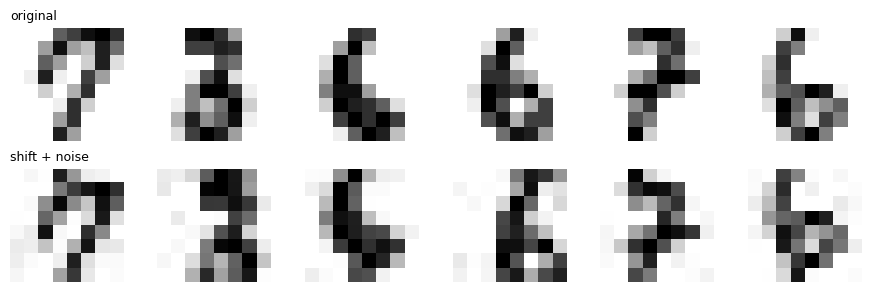

In [12]:
class Compose:
    def __init__(self, *fns): self.fns = fns
    def __call__(self, x):
        for f in self.fns: x = f(x)
        return x

def random_shift(max_px, rng):
    """Shift each 8x8 image by up to max_px pixels, padding with zeros."""
    def f(X):
        out = np.zeros_like(X)
        imgs = X.reshape(-1, 8, 8)
        for i, img in enumerate(imgs):
            dy, dx = rng.integers(-max_px, max_px + 1, 2)
            out[i] = np.roll(np.roll(img, dy, 0), dx, 1).ravel()
        return out
    return f

def gaussian_noise(std, rng):
    return lambda X: np.clip(X + rng.normal(0, std, X.shape), 0, 1)

class DataLoader:
    def __init__(self, X, y, batch_size, shuffle=True, transform=None, seed=0):
        self.X, self.y, self.B, self.shuffle = X, y, batch_size, shuffle
        self.transform, self.rng = transform, np.random.default_rng(seed)
    def __iter__(self):
        idx = self.rng.permutation(len(self.X)) if self.shuffle else np.arange(len(self.X))
        for i in range(0, len(idx), self.B):
            j = idx[i:i + self.B]
            Xb = self.X[j] if self.transform is None else self.transform(self.X[j])
            yield (Tensor(Xb, requires_grad=False),
                   Tensor(one_hot(self.y[j]), requires_grad=False), self.y[j])

aug_rng = np.random.default_rng(0)
augment = Compose(random_shift(1, aug_rng), gaussian_noise(0.05, aug_rng))

sample = X_train[:6]
fig, ax = plt.subplots(2, 6, figsize=(9, 3))
for i in range(6):
    ax[0, i].imshow(sample[i].reshape(8, 8), cmap="gray_r"); ax[0, i].axis("off")
    ax[1, i].imshow(augment(sample[i:i+1]).reshape(8, 8), cmap="gray_r"); ax[1, i].axis("off")
ax[0, 0].set_title("original", fontsize=9, loc="left")
ax[1, 0].set_title("shift + noise", fontsize=9, loc="left")
plt.tight_layout(); plt.show()

## 2f. Training a residual network — with no `backward` written anywhere

Every piece now plugs together: a model built from modules, a loss module, an optimizer that finds
the parameters by recursion, and a data loader. Swapping any one of them leaves the others
untouched.

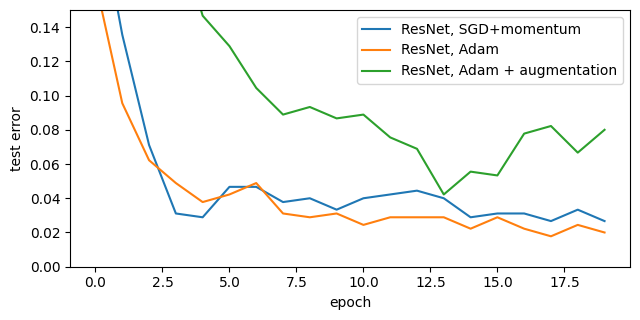

configuration                       best   final
------------------------------------------------
ResNet, SGD+momentum              0.0267  0.0267
ResNet, Adam                      0.0178  0.0200
ResNet, Adam + augmentation       0.0422  0.0800


In [13]:
def build_resnet(seed):
    r = np.random.default_rng(seed)
    return Sequential(
        Linear(64, 96, r), ReLU(),
        Residual(Sequential(Linear(96, 96, r), ReLU(), Linear(96, 96, r))),
        ReLU(),
        Linear(96, 10, r))

def evaluate(model, X, y):
    model.eval()
    logits = model(Tensor(X, requires_grad=False)).data
    model.train()
    return float((np.argmax(logits, 1) != y).mean())

def fit(model, opt, loader, epochs):
    loss_fn, hist = SoftmaxLoss(), []
    for _ in range(epochs):
        for Xb, Yb, _ in loader:
            opt.reset_grad()
            loss_fn(model(Xb), Yb).backward()
            opt.step()
        hist.append(evaluate(model, X_test, y_test))
    return hist

runs = {}
m1 = build_resnet(0)
runs["ResNet, SGD+momentum"] = fit(m1, SGD(m1.parameters(), lr=0.2, momentum=0.9),
                                   DataLoader(X_train, y_train, 64), epochs=20)
m2 = build_resnet(0)
runs["ResNet, Adam"] = fit(m2, Adam(m2.parameters(), lr=2e-3),
                           DataLoader(X_train, y_train, 64), epochs=20)
m3 = build_resnet(0)
runs["ResNet, Adam + augmentation"] = fit(m3, Adam(m3.parameters(), lr=2e-3),
                           DataLoader(X_train, y_train, 64,
                                      transform=Compose(random_shift(1, np.random.default_rng(1)),
                                                        gaussian_noise(0.05, np.random.default_rng(2)))),
                           epochs=20)

plt.figure(figsize=(6.5, 3.3))
for name, h in runs.items():
    plt.plot(h, label=name)
plt.xlabel("epoch"); plt.ylabel("test error"); plt.ylim(0, 0.15); plt.legend()
plt.tight_layout(); plt.show()

print(f"{'configuration':<32}{'best':>8}{'final':>8}")
print("-" * 48)
for name, h in runs.items():
    print(f"{name:<32}{min(h):>8.4f}{h[-1]:>8.4f}")

Three runs, and between them only one component changed at a time — the optimizer, then the data
pipeline. The model and loss were not touched.

The augmentation result is worth being honest about: here it makes things **worse**. A one-pixel
shift on an 8×8 image moves the digit by an eighth of the frame — on a 28×28 MNIST digit the same
fraction would be a shift of three or four pixels — and twenty epochs is too short to benefit from
the extra variety. Augmentation earns its reputation on larger images with transforms matched to
the data. What this run does demonstrate is the point of the lecture: trying it cost one argument
to the loader, and nothing else changed. That interchangeability is the practical meaning of
the lecture: to try a new optimizer you replace the optimizer; to try augmentation you replace the
loader.

## The decision that made it work

A Caffe layer is both a unit of **composition** and a unit of **gradient computation** — it must
implement `backward`. Writing a residual block in Caffe means deriving its backward pass by hand.

Second-generation frameworks split those across two levels. **Gradients live at the tensor
level** (Part 2a), solved once. **Composition lives at the module level** (Part 2b), where a new
block needs only `forward`. Count the `backward` methods written in Part 2 above the tensor level:
zero. That separation is what made new architectures cheap to try.

## Summary

- Caffe: layers with hand-written `forward`/`backward`. TensorFlow 1.0: declare a static graph, then run it — requesting $v_3$ skipped $v_4$. PyTorch: build as you run, so Python `if` works on real values.
- Declarative buys whole-graph optimisation and remote execution; imperative buys dynamic graphs and debuggability.
- A `Module` is tensor in, tensor out, owns and initialises its parameters, and reports them recursively.
- A loss is tensor in, scalar out, so objectives add — verified: grad of the sum is the sum of grads.
- An optimizer owns auxiliary state. L2 in the loss and weight decay in the update gave identical parameters.
- Transforms compose into a data pipeline the same way modules compose into a model.